============================================================
FPS PREDICTION PIPELINE
============================================================

DATASET OVERVIEW|
-------------------
This dataset contains benchmark results measuring Frames Per Second (FPS)
for video games executed on various hardware configurations.

Each observation represents a unique combination of:

• CPU characteristics (e.g., model, frequency, cores, cache)
• GPU characteristics (e.g., architecture, memory, bandwidth)
• Game configuration (name, resolution, quality setting)

The target variable is:
• FPS (Frames Per Second)

Data sources:
• userbenchmark: extracted from histogram distributions (discrete, noisy)
• fpsbenchmark: direct benchmark measurements

------------------------------------------------------------

DATA CHARACTERISTICS
----------------------
• Multiple records may exist for the same configuration
• High-cardinality categorical features (CPU, GPU, Game)
• Missing values indicated as "?"
• Skewed and noisy FPS distribution

These properties require careful handling to avoid data leakage
and ensure robust model performance.

------------------------------------------------------------

MODELING APPROACH
-------------------
• Target transformation:
  - log1p(FPS) to stabilize variance

• Leakage prevention:
  - Group-based splitting on hardware + game configuration

• Feature encoding:
  - Target encoding for categorical variables

• Models:
  - LightGBM
  - XGBoost
  - CatBoost

• Validation:
  - GroupKFold cross-validation

• Evaluation metrics:
  - RMSE (primary)
  - MAE
  - R²

------------------------------------------------------------
p.s i'm being petty with this


In [1]:

import warnings
warnings.filterwarnings("ignore")

import random
import numpy as np
import pandas as pd

from scipy.io import arff

from sklearn.model_selection import (
    GroupShuffleSplit,
    GroupKFold
)

from sklearn.preprocessing import (
        OneHotEncoder,
        StandardScaler,
        PowerTransformer
    )
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

from scipy.stats import (
    ttest_ind,
    mannwhitneyu,
    pearsonr,
    spearmanr,
    shapiro,
    levene,
    chi2_contingency
)

from sklearn.base import clone

from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor, Pool

from category_encoders import TargetEncoder

import joblib


CONFIG
-------------------

In [2]:

# ============================================================
# CONFIG
# ============================================================

SEED = 42
TEST_SIZE = 0.3
N_SPLITS = 3

np.random.seed(SEED)
random.seed(SEED)



DATASET LOADING
-------------------

In [3]:

# ============================================================
# DATA LOADING
# ============================================================

def load_data(path: str) -> pd.DataFrame:
    """
    Load and clean dataset from ARFF file.

    Steps:
    - Parses ARFF into a pandas DataFrame
    - Decodes byte-string categorical values
    - Replaces '?' with NaN
    - Attempts numeric type conversion
    - Fixes known column naming issues

    Parameters:
    ----------
    path : str
        File path to the ARFF dataset

    Returns:
    -------
    pd.DataFrame
        Cleaned dataset ready for feature engineering
    """

    # ============================================================
    # LOAD ARFF
    # ============================================================

    raw_data, _ = arff.loadarff(path)

    df = pd.DataFrame(raw_data)

    # ============================================================
    # FIX BYTE STRINGS
    # ============================================================

    for col in df.columns:

        if df[col].dtype == object:

            df[col] = df[col].apply(
                lambda x: x.decode("utf-8")
                if isinstance(x, bytes)
                else x
            )

    # ============================================================
    # FIX COLUMN NAMES
    # ============================================================

    df.columns = (
        df.columns
        .str.strip()
        .str.replace("'", "", regex=False)
    )

    # Fix typo
    if "GpuBus nterface" in df.columns:
        df.rename(
            columns={
                "GpuBus nterface": "GpuBusInterface"
            },
            inplace=True
        )

    # ============================================================
    # REPLACE MISSING SYMBOLS
    # ============================================================

    df.replace("?", np.nan, inplace=True)

    # ============================================================
    # ONLY CONVERT TRUE NUMERIC COLUMNS
    # ============================================================

    categorical_cols = [
        "CpuName",
        "GpuName",
        "GpuArchitecture",
        "GpuBusInterface",
        "GpuMemoryType",
        "GameName",
        "GameSetting",
        "Dataset"
    ]

    categorical_cols = [
        c for c in categorical_cols
        if c in df.columns
    ]

    numeric_cols = [
        c for c in df.columns
        if c not in categorical_cols
    ]

    for col in numeric_cols:
        df[col] = pd.to_numeric(
            df[col],
            errors="coerce"
        )

    # ============================================================
    # DEBUG
    # ============================================================

    print("\nDataset Info:")
    print(df.info())

    print("\nCategorical Columns:")
    print(df[categorical_cols].head())

    return df


FEATURE ENGINEERING
-------------------

In [4]:

# ============================================================
# FEATURE ENGINEERING
# ============================================================

def feature_engineering(df):
    """
    Generate additional derived features to improve model performance.

    Features:
    - GpuComputeDensity: log-scaled compute per die size
    - GpuMemoryEfficiency: bandwidth per memory size
    - CpuThreadPerformance: CPU frequency * threads

    Parameters:
    ----------
    df : pd.DataFrame
        Input dataset

    Returns:
    -------
    pd.DataFrame
        Dataset with additional engineered features
    """

    df = df.copy()

    df["GpuComputeDensity"] = np.log1p(
        df["GpuFP32Performance"] / (df["GpuDieSize"] + 1e-6)
    )

    df["GpuMemoryEfficiency"] = (
        df["GpuBandwidth"] / (df["GpuMemorySize"] + 1)
    )

    df["CpuThreadPerformance"] = (
        df["CpuFrequency"] * df["CpuNumberOfThreads"]
    )

    return df




GROUPING
-------------------

In [5]:
# ============================================================
# GROUP CREATION
# ============================================================

def create_group(df):

    """
    Create stable groups for grouped CV.

    Group by:
    - CPU
    - GPU

    Avoid:
    - Resolution
    - Settings

    because they create too many tiny groups.
    """

    import pandas as pd

    required_cols = [
        "CpuName",
        "GpuName",
    ]

    # Ensure columns exist
    missing_cols = [
        c for c in required_cols
        if c not in df.columns
    ]

    if len(missing_cols) > 0:
        raise ValueError(
            f"Missing grouping columns: {missing_cols}"
        )

    temp = df[required_cols].copy()

    # Fix missing values
    temp = temp.fillna("missing")

    # Convert to string
    temp = temp.astype(str)

    # Create group id
    groups = temp.agg("_".join, axis=1)

    # ============================================================
    # DEBUG
    # ============================================================

    print(f"Dataset rows: {len(df)}")
    print(f"Unique groups: {groups.nunique()}")

    vc = groups.value_counts()

    print("\nTop groups:")
    print(vc.head())

    print("\nSmallest groups:")
    print(vc.tail())

    return groups


PREPROCESSING PIPELINE
-------------------

In [6]:

# ============================================================
# PREPROCESSOR 
# ============================================================
from sklearn.preprocessing import OneHotEncoder


def fix_string_dtype(df: pd.DataFrame) -> pd.DataFrame:
    """
    Convert pandas 'string' dtype and categorical dtype to 'object'.
    Required for sklearn compatibility.
    """
    df = df.copy()

    for col in df.columns:
        if str(df[col].dtype).startswith("string"):
            df[col] = df[col].astype("object")

    return df

def build_preprocessor(X, y):
    
    """
    Construct preprocessing pipeline.

    Processing:
    - Numeric features:
        • Median imputation
        • Standard scaling
    - Categorical features:
        • Mode imputation
        • One-hot encoding

    Parameters:
    ----------
    X : pd.DataFrame
        Feature matrix
    y : pd.Series
        Target variable (used for target encoding)

    Returns:
    -------
    ColumnTransformer
        Configured preprocessing pipeline
    """

    X = X.copy()

    string_cols = X.select_dtypes(include=["string"]).columns

    for col in string_cols:
        X[col] = X[col].astype(object)

    # ============================================================
    # COLUMN DETECTION
    # ============================================================

    categorical_cols = X.select_dtypes(
        include=["object", "category"]
    ).columns.tolist()

    numerical_cols = X.select_dtypes(
        include=[np.number]
    ).columns.tolist()

    # ============================================================
    # NUMERICAL PIPELINE
    # ============================================================

    numerical_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("power", PowerTransformer(method="yeo-johnson")),
        ("scaler", StandardScaler())
    ])

    # ============================================================
    # CATEGORICAL PIPELINE
    # ============================================================

    categorical_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False
        ))
    ])

    # ============================================================
    # COLUMN TRANSFORMER
    # ============================================================

    preprocessor = ColumnTransformer([
        ("num", numerical_pipeline, numerical_cols),
        ("cat", categorical_pipeline, categorical_cols)
    ])

    return preprocessor




EVALUATE METRIC
-------------------

In [7]:

# ============================================================
# METRICS
# ============================================================

def evaluate(y_true_log, y_pred_log):
    
    """
    Evaluate model performance on original scale.

    Converts log-transformed predictions back to original FPS scale
    before computing metrics.

    Metrics:
    - RMSE (primary)
    - MAE
    - R²

    Parameters:
    ----------
    y_true_log : np.ndarray
        Ground truth (log-transformed)
    y_pred_log : np.ndarray
        Predictions (log-transformed)

    Returns:
    -------
    dict
        Dictionary of evaluation metrics
    """

    """Evaluate using both log and original scale."""
    y_true = np.expm1(y_true_log)
    y_pred = np.expm1(y_pred_log)

    return {
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MAE": mean_absolute_error(y_true, y_pred),
        "R2": r2_score(y_true, y_pred)
    }




CROSS VALIDATION
-------------------

In [8]:
# ============================================================
# CROSS-VALIDATION TRAINING
# ============================================================

def train_with_group_cv(model, X, y, groups, is_catboost=False):

    """
    Train model using GroupKFold cross-validation.

    Prevents leakage between folds using grouped splits.

    Supports:
    - LightGBM
    - XGBoost
    - CatBoost
    - sklearn models

    Returns:
    -------
    best_model, mean_cv_rmse
    """


    # ============================================================
    # FIX GROUPS
    # ============================================================

    groups = pd.Series(groups).reset_index(drop=True)
    groups = groups.fillna("missing").astype(str)

    unique_groups = groups.nunique()

    print(f"Unique groups: {unique_groups}")

    if unique_groups < 2:
        raise ValueError(
            f"Need at least 2 unique groups, got {unique_groups}"
        )

    # Auto-adjust folds
    n_splits = min(N_SPLITS, unique_groups)

    print(f"Using {n_splits} folds")

    gkf = GroupKFold(n_splits=n_splits)

    scores = []
    best_model = None
    best_score = np.inf

    # ============================================================
    # CV LOOP
    # ============================================================

    for fold, (train_idx, val_idx) in enumerate(
        gkf.split(X, y, groups)
    ):

        print(f"\nFold {fold+1}")

        # ============================================================
        # SAFE INDEXING
        # ============================================================

        if isinstance(X, pd.DataFrame):
            X_tr = X.iloc[train_idx]
            X_val = X.iloc[val_idx]
        else:
            X_tr = X[train_idx]
            X_val = X[val_idx]

        if isinstance(y, pd.Series):
            y_tr = y.iloc[train_idx]
            y_val = y.iloc[val_idx]
        else:
            y_tr = y[train_idx]
            y_val = y[val_idx]

        # Clone model each fold
        current_model = clone(model)

        # ============================================================
        # CATBOOST
        # ============================================================

        if is_catboost:

            # ============================================================
            # FIND CATEGORICAL COLUMNS
            # ============================================================

            cat_cols = X_tr.select_dtypes(
                include=["object", "category"]
            ).columns.tolist()

            # ============================================================
            # FIX CATBOOST NaN ISSUE
            # ============================================================

            for col in cat_cols:

                X_tr[col] = (
                    X_tr[col]
                    .fillna("missing")
                    .astype(str)
                )

                X_val[col] = (
                    X_val[col]
                    .fillna("missing")
                    .astype(str)
                )

            # ============================================================
            # CREATE POOLS
            # ============================================================

            train_pool = Pool(
                X_tr,
                y_tr,
                cat_features=cat_cols
            )

            val_pool = Pool(
                X_val,
                y_val,
                cat_features=cat_cols
            )

            # ============================================================
            # TRAIN
            # ============================================================

            current_model.fit(
                train_pool,
                eval_set=val_pool,
                early_stopping_rounds=50,
                verbose=0
            )

            preds = current_model.predict(X_val)

        # ============================================================
        # LIGHTGBM / OTHERS
        # ============================================================

        else:

            try:

                current_model.fit(
                    X_tr,
                    y_tr,
                    eval_set=[(X_val, y_val)]
                )

            except TypeError:

                current_model.fit(X_tr, y_tr)

            preds = current_model.predict(X_val)

        # ============================================================
        # RMSE
        # ============================================================

        rmse = np.sqrt(
            mean_squared_error(
                np.expm1(y_val),
                np.expm1(preds)
            )
        )

        print(f"Fold RMSE: {rmse:.4f}")

        scores.append(rmse)

        # Save best model
        if rmse < best_score:
            best_score = rmse
            best_model = current_model

    # ============================================================
    # FINAL SCORE
    # ============================================================

    mean_rmse = np.mean(scores)

    print("\nCV Scores:", scores)
    print(f"Mean RMSE: {mean_rmse:.4f}")

    return best_model, mean_rmse


EDA & PLOTTING
-------------------

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

def run_eda(df: pd.DataFrame):
    """
    Perform Exploratory Data Analysis (EDA).

    Handles:
    - Missing values safely
    - Corrupted categorical columns
    - Visualization stability

    Generates:
    - Distribution plots
    - Relationship plots
    - Correlation heatmap
    """

    print("\n===== EDA: BASIC INFO =====")
    print(df.shape)
    print(df.describe())

    df = df.copy()
    df = df.dropna(subset=["FPS"])

    # --------------------------------------------------------
    # 1. TARGET DISTRIBUTION
    # --------------------------------------------------------
    plt.figure(figsize=(8, 5))
    sns.histplot(df["FPS"], bins=50, kde=True)
    plt.title("FPS Distribution")
    plt.xlabel("FPS")
    plt.ylabel("Frequency")
    plt.show()

    print("Insight 1: FPS distribution is typically right-skewed → log transform is useful.\n")

    # --------------------------------------------------------
    # 2. FPS BY GAME SETTING 
    # --------------------------------------------------------
    if "GameSetting" in df.columns:

        temp = df[["GameSetting", "FPS"]].dropna().copy()
        temp["GameSetting"] = temp["GameSetting"].astype(str)

        # Remove invalid entries
        temp = temp[temp["GameSetting"] != "nan"]

        if len(temp) > 0:
            plt.figure(figsize=(8, 5))
            sns.boxplot(data=temp, x="GameSetting", y="FPS")
            plt.title("FPS by Game Setting")
            plt.show()

            print("Insight 2: Higher settings don’t always reduce FPS significantly—median performance stays similar, but higher settings show slightly better stability with extreme outliers across all levels..\n")

    # --------------------------------------------------------
    # 3. FPS VS GPU PERFORMANCE 
    # --------------------------------------------------------
    if "GpuFP32Performance" in df.columns:

        temp = df[["GpuFP32Performance", "FPS"]].dropna()

        if len(temp) > 0:
            sample_df = temp.sample(min(3000, len(temp)))

            plt.figure(figsize=(8, 5))
            sns.scatterplot(
                data=sample_df,
                x="GpuFP32Performance",
                y="FPS",
                alpha=0.6
            )
            plt.title("FPS vs GPU FP32 Performance")
            plt.show()

            print("Insight 3: Higher GPU FP32 performance generally increases FPS, but the relationship is weak and highly scattered—indicating other bottlenecks (CPU, memory, or game optimization) significantly affect performance..\n")

    # --------------------------------------------------------
    # 4. FPS BY DATASET SOURCE 
    # --------------------------------------------------------
    if "Dataset" in df.columns:

        temp = df[["Dataset", "FPS"]].dropna().copy()
        temp["Dataset"] = temp["Dataset"].astype(str)

        if len(temp) > 0:
            plt.figure(figsize=(8, 5))
            sns.boxplot(data=temp, x="Dataset", y="FPS")
            plt.title("FPS Distribution by Dataset Source")
            plt.show()

            print("Insight 4: UserBenchmark shows higher variability and extreme FPS outliers, while FPSBenchmark provides more consistent and stable performance distributions..\n")

    # --------------------------------------------------------
    # 5. CORRELATION HEATMAP 
    # --------------------------------------------------------
    numeric_df = df.select_dtypes(include=["int64", "float64"])

    if "FPS" in numeric_df.columns:

        corr = numeric_df.corr()

        plt.figure(figsize=(10, 7))
        sns.heatmap(
            corr[["FPS"]].sort_values(by="FPS", ascending=False),
            annot=True,
            cmap="coolwarm"
        )
        plt.title("Feature Correlation with FPS")
        plt.show()

        print("Insight 5: GPU-related features have the strongest (but still moderate) positive correlation with FPS, indicating performance is influenced by multiple factors rather than a single dominant metric..\n")

    # --------------------------------------------------------
    # 6. RESOLUTION VS FPS 
    # --------------------------------------------------------
    if "GameResolution" in df.columns:

        temp = df[df["FPS"] < 400]

        sns.boxplot(data=temp, x="GameResolution", y="FPS")
        plt.title("FPS by Resolution (Filtered)")
        plt.show()
        print("Insight 6: FPS does not strictly decrease with higher resolution—1440p delivers similar median performance to 1080p but with more consistency..")

    print("===== EDA COMPLETE =====\n")

STATISTICAL INFERENCE & HYPOTHESIS TESTING
-------------------

In [ ]:
def run_statistical_inference(df: pd.DataFrame):
    """
    Perform statistical inference and hypothesis testing.
    """

    print("\n" + "=" * 70)
    print("STATISTICAL INFERENCE & HYPOTHESIS TESTING")
    print("=" * 70)

    # ========================================================
    # 1. NORMALITY TEST
    # ========================================================

    print("\n[1] SHAPIRO-WILK NORMALITY TEST")

    sample_fps = df["FPS"].dropna()
    stat, p = shapiro(sample_fps)

    print(f"Statistic : {stat:.4f}")
    print(f"P-value   : {p:.3e}")

    if p > 0.05:
        print("Result    : FPS distribution appears NORMAL")
    else:
        print("Result    : FPS distribution is NOT normal")

    # ========================================================
    # 2. CORRELATION TEST
    # ========================================================

    print("\n[2] CORRELATION TEST")

    numeric_cols = df.select_dtypes(include=np.number).columns

    corr_results = []

    for col in numeric_cols:

        if col == "FPS":
            continue

        temp = df[[col, "FPS"]].dropna()

        if len(temp) < 10:
            continue

        corr, pval = pearsonr(temp[col], temp["FPS"])

        corr_results.append({
            "Feature": col,
            "Pearson_r": corr,
            "P_value": f"{pval:.3e}"
        })

    corr_df = pd.DataFrame(corr_results)
    corr_df = corr_df.sort_values("Pearson_r", key=np.abs, ascending=False)

    print(corr_df.head(10))

    # ========================================================
    # 3. TWO-SAMPLE HYPOTHESIS TEST
    # ========================================================

    print("\n[3] HIGH-END VS LOW-END GPU FPS COMPARISON (TOP/BOTTOM 30%)")

    if "GpuBaseClock" in df.columns and "GameName" in df.columns:

        game_results = []

        for game in df["GameName"].unique():

            game_df = df[df["GameName"] == game].copy()

            if len(game_df) < 30:
                continue

            low_threshold = game_df["GpuBaseClock"].quantile(0.30)
            high_threshold = game_df["GpuBaseClock"].quantile(0.70)

            low_gpu = game_df[
                game_df["GpuBaseClock"] <= low_threshold
            ]["FPS"].dropna()

            high_gpu = game_df[
                game_df["GpuBaseClock"] >= high_threshold
            ]["FPS"].dropna()

            if len(low_gpu) < 5 or len(high_gpu) < 5:
                continue

            # Variance test
            _, lev_p = levene(high_gpu, low_gpu)

            equal_var = lev_p > 0.05

            # T-test
            t_stat, t_p = ttest_ind(
                high_gpu,
                low_gpu,
                equal_var=equal_var
            )

            # Mann-Whitney U test
            u_stat, u_p = mannwhitneyu(
                high_gpu,
                low_gpu,
                alternative="two-sided"
            )

            game_results.append({
                "GameName": game,
                "High_GPU_Mean_FPS": high_gpu.mean(),
                "Low_GPU_Mean_FPS": low_gpu.mean(),
                "FPS_Difference": high_gpu.mean() - low_gpu.mean(),
                "T_P_value": t_p,
                "MWU_P_value": u_p
            })

        results_df = pd.DataFrame(game_results)

        print(results_df.head(10))

        print("\nSUMMARY")
        print("-" * 50)

        sig_ttest = (results_df["T_P_value"] < 0.05).sum()
        sig_mwu = (results_df["MWU_P_value"] < 0.05).sum()

        print(f"Games Tested                : {len(results_df)}")
        print(f"Significant T-Tests         : {sig_ttest}")
        print(f"Significant MWU Tests       : {sig_mwu}")

        print(
            f"Average FPS Difference      : "
            f"{results_df['FPS_Difference'].mean():.2f}"
        )
    print("\nStatistical inference completed.\n")




MAIN
-------------------

In [11]:

# ============================================================
# MAIN
# ============================================================

def main():
    
    """
    Execute full FPS prediction pipeline.

    Workflow:
    1. Load and clean dataset
    2. Apply feature engineering
    3. Log-transform target
    4. Perform group-aware train/test split
    5. Build preprocessing pipeline
    6. Train models using GroupKFold CV:
        - LightGBM
        - XGBoost
        - CatBoost
    7. Evaluate on held-out test set
    8. Select best-performing model
    9. Save full pipeline (model + preprocessor)

    Outputs:
    -------
    - Prints model performance comparison
    - Saves trained pipeline to 'fps_pipeline.pkl'
    """


    df = load_data("fps-in-video-games.arff")
    df = feature_engineering(df)

    run_eda(df)
    run_statistical_inference(df)

    # Log transform target
    y = np.log1p(df["FPS"])
    X = df.drop(columns=["FPS"])

    print("Original dataset shape:", df.shape)

    groups = create_group(df)

    print("Groups unique:", groups.nunique())

    assert len(groups) == len(df)
    

    # Split
    splitter = GroupShuffleSplit(n_splits=1, test_size=TEST_SIZE, random_state=SEED)
    train_idx, test_idx = next(splitter.split(X, y, groups))

    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    groups_train = groups.iloc[train_idx]


    string_cols_train = X_train.select_dtypes(include=["string"]).columns
    string_cols_test = X_test.select_dtypes(include=["string"]).columns

    for col in string_cols_train:
        X_train[col] = X_train[col].astype(object)

    for col in string_cols_test:
        X_test[col] = X_test[col].astype(object)

    # ============================================================
    # PREPROCESSING
    # ============================================================

    preprocessor = build_preprocessor(X_train, y_train)

    X_train_prep = preprocessor.fit_transform(X_train, y_train)
    X_test_prep = preprocessor.transform(X_test)

    # Convert to DataFrame (for consistent indexing)
    X_train_prep = pd.DataFrame(X_train_prep)
    X_test_prep = pd.DataFrame(X_test_prep)

    results = []

    # # --------------------------------------------------------
    # # LightGBM
    # --------------------------------------------------------
    lgbm = LGBMRegressor(
        n_estimators=1000,
        learning_rate=0.05,
        random_state=SEED
    )

    best_lgbm, score = train_with_group_cv(
        lgbm,
        X_train_prep,
        y_train,
        groups_train
    )

    preds = best_lgbm.predict(X_test_prep)
    metrics = evaluate(y_test, preds)
    results.append({"Model": "LightGBM", **metrics})

    # # --------------------------------------------------------
    # # XGBoost
    # # --------------------------------------------------------
    xgb = XGBRegressor(
        n_estimators=1000,
        learning_rate=0.05,
        objective="reg:squarederror",
        random_state=SEED
    )

    best_xgb, score = train_with_group_cv(
        xgb,
        X_train_prep,
        y_train,
        groups_train
    )

    preds = best_xgb.predict(X_test_prep)
    metrics = evaluate(y_test, preds)
    results.append({"Model": "XGBoost", **metrics})

    # --------------------------------------------------------
    # CatBoost
    # --------------------------------------------------------
    cat = CatBoostRegressor(
        iterations=1000,
        learning_rate=0.05,
        depth=6,
        loss_function="RMSE",
        random_seed=SEED,
        verbose=0
    )

    best_cat, score = train_with_group_cv(
        cat,
        X_train_prep,
        y_train,
        groups_train,
        is_catboost=True
    )

    preds = best_cat.predict(X_test_prep)
    metrics = evaluate(y_test, preds)
    results.append({"Model": "CatBoost", **metrics})

    # --------------------------------------------------------
    # RESULTS
    # --------------------------------------------------------
    results_df = pd.DataFrame(results).sort_values("RMSE")
    print("\nMODEL COMPARISON:")
    print(results_df)

    best_row = results_df.iloc[0]
    best_model_name = best_row["Model"]

    if best_model_name == "CatBoost":
        final_model = best_cat
        model_type = "catboost"
    elif best_model_name == "LightGBM":
        final_model = best_lgbm
        model_type = "sklearn"
    else:
        final_model = best_xgb
        model_type = "sklearn"

    # Save full pipeline
    joblib.dump({
        "model_type": model_type,
        "preprocessor": preprocessor,
        "model": final_model
    }, "fps_pipeline.pkl")

    print(f"\n✅ Saved best model: {best_model_name}")




Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 425833 entries, 0 to 425832
Data columns (total 45 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   CpuName                    425833 non-null  str    
 1   CpuNumberOfCores           425833 non-null  float64
 2   CpuNumberOfThreads         425833 non-null  float64
 3   CpuBaseClock               425833 non-null  float64
 4   CpuCacheL1                 425833 non-null  float64
 5   CpuCacheL2                 425833 non-null  float64
 6   CpuCacheL3                 420778 non-null  float64
 7   CpuDieSize                 223299 non-null  float64
 8   CpuFrequency               425833 non-null  float64
 9   CpuMultiplier              425833 non-null  float64
 10  CpuMultiplierUnlocked      425833 non-null  int64  
 11  CpuProcessSize             425833 non-null  float64
 12  CpuTDP                     425833 non-null  float64
 13  CpuNumberOfTransistors   

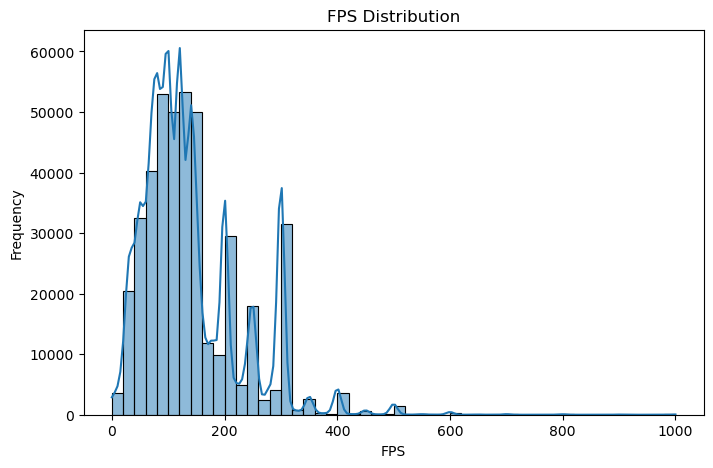

Insight 1: FPS distribution is typically right-skewed → log transform is useful.



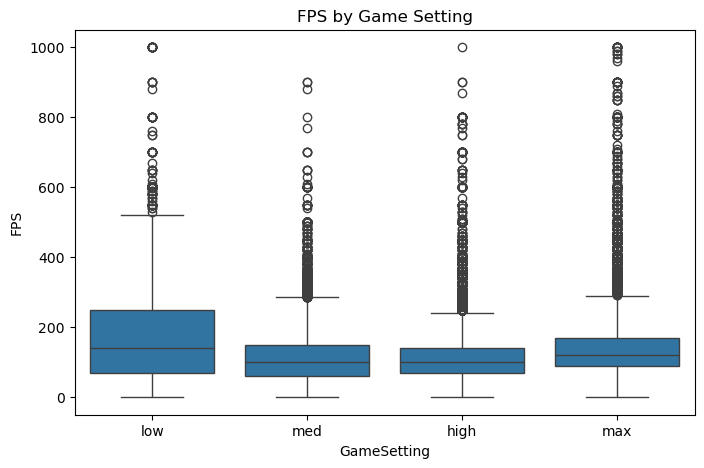

Insight 2: Higher settings don’t always reduce FPS significantly—median performance stays similar, but higher settings show slightly better stability with extreme outliers across all levels..



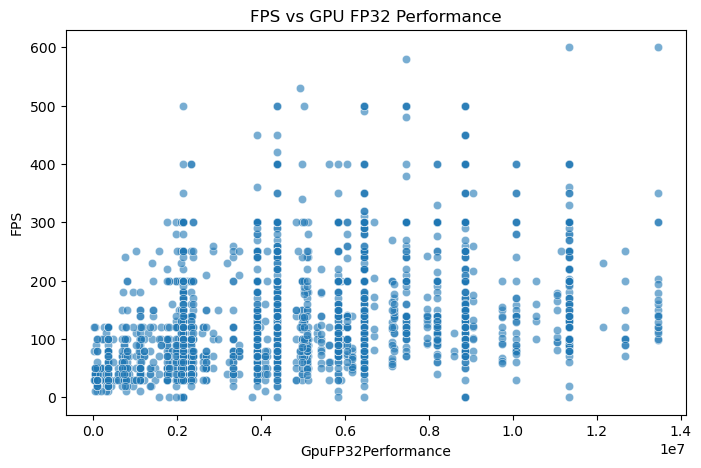

Insight 3: Higher GPU FP32 performance generally increases FPS, but the relationship is weak and highly scattered—indicating other bottlenecks (CPU, memory, or game optimization) significantly affect performance..



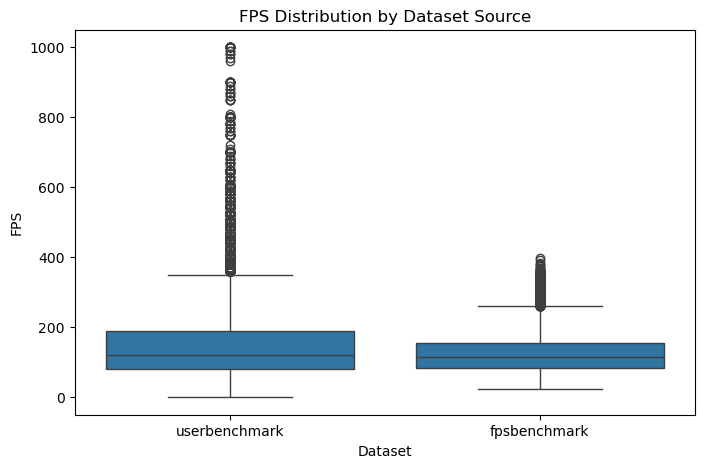

Insight 4: UserBenchmark shows higher variability and extreme FPS outliers, while FPSBenchmark provides more consistent and stable performance distributions..



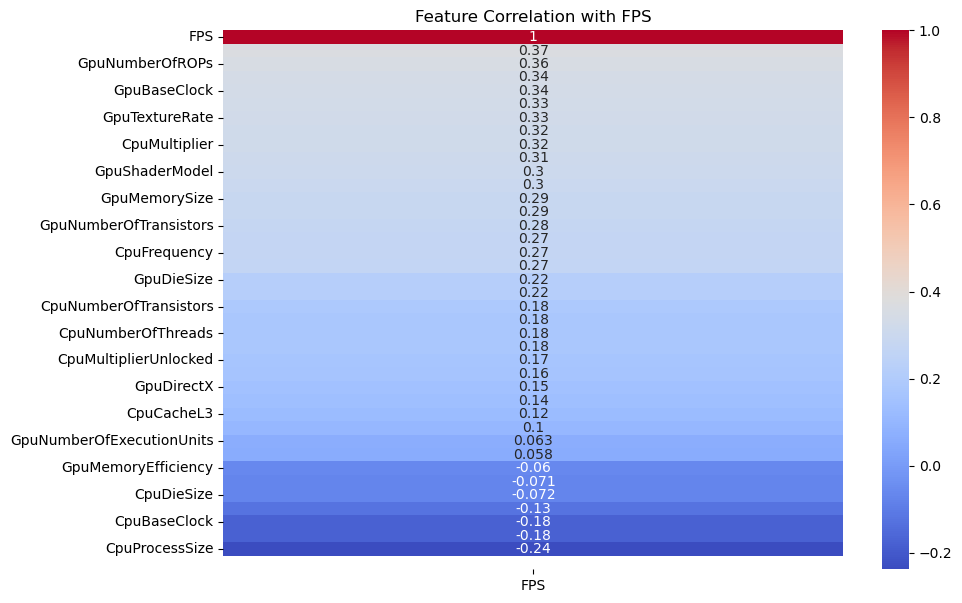

Insight 5: GPU-related features have the strongest (but still moderate) positive correlation with FPS, indicating performance is influenced by multiple factors rather than a single dominant metric..



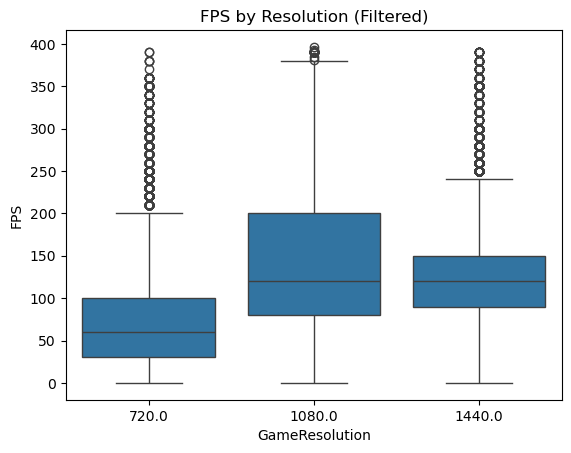

Insight 6: FPS does not strictly decrease with higher resolution—1440p delivers similar median performance to 1080p but with more consistency..
===== EDA COMPLETE =====


STATISTICAL INFERENCE & HYPOTHESIS TESTING

[1] SHAPIRO-WILK NORMALITY TEST
Statistic : 0.8882
P-value   : 9.335e-145
Result    : FPS distribution is NOT normal

[2] CORRELATION TEST
                    Feature  Pearson_r    P_value
26             GpuPixelRate   0.370195  0.000e+00
28          GpuNumberOfROPs   0.355878  0.000e+00
13            CpuTurboClock   0.341268  0.000e+00
15             GpuBaseClock   0.335053  0.000e+00
21       GpuFP32Performance   0.329099  0.000e+00
32           GpuTextureRate   0.325536  0.000e+00
16            GpuBoostClock   0.320595  0.000e+00
8             CpuMultiplier   0.319486  0.000e+00
17  GpuNumberOfComputeUnits   0.312465  0.000e+00
29           GpuShaderModel   0.304819  0.000e+00

[3] HIGH-END VS LOW-END GPU FPS COMPARISON (TOP/BOTTOM 30%)
                       GameName  Hi

In [12]:

# ============================================================
# RUN
# ============================================================

if __name__ == "__main__":
    main()